In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Load Dataset

In [2]:
df = pd.read_excel("dataset.xlsx")
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


Dataset *Information*

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [ ]:
df.shape

(1440, 3)

In [ ]:
df.shape

(1440, 3)

In [ ]:
df.columns

Index(['title', 'rating', 'body'], dtype='object')

Missing Values

In [ ]:
df.isnull().sum()
(df.isnull().sum()/len(df))*100

,0
title,0.0
rating,0.0
body,0.0


Duplicate Values

In [ ]:
df.duplicated().sum()

np.int64(0)

Combine Title and Review

In [ ]:
df["Review"] = df["title"].fillna('') + " " + df["body"].fillna('')

In [ ]:
df.head()

,title,rating,body,Review
0,Horrible product,1,Very disappointed with the overall performance...,Horrible product Very disappointed with the ov...
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Camera quality is not like 48 megapixel Camera...
2,Overall,4,"Got the mobile on the launch date,Battery must...","Overall Got the mobile on the launch date,Batt..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,A big no from me 1. It doesn't work with 5.0GH...
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Put your money somewhere else Not worth buying...


Detect Language

In [ ]:
pip install langdetect deep-translator

In [ ]:
from langdetect import detect

def detect_language(text):
    try:
        return detect(str(text))
    except:
        return "unknown"

df["Language"] = df["Review"].apply(detect_language)

In [ ]:
df["Language"].value_counts()

,count
Language,
en,1411
hi,11
ca,4
id,4
af,3
et,2
lv,1
ml,1
de,1


Translate Every Non-English Review

In [ ]:
from deep_translator import GoogleTranslator

def translate_to_english(text, lang):
    try:
        if lang == "en":
            return text
        else:
            return GoogleTranslator(source="auto", target="en").translate(text)
    except:
        return text

df["Translated_Review"] = df.apply(
    lambda row: translate_to_english(row["Review"], row["Language"]),
    axis=1
)

In [ ]:
df["Translated_Review"]

,Translated_Review
0,Horrible product Very disappointed with the ov...
1,Camera quality is not like 48 megapixel Camera...
2,"Overall Got the mobile on the launch date,Batt..."
3,A big no from me 1. It doesn't work with 5.0GH...
4,Put your money somewhere else Not worth buying...
...,...
1435,Excellent mobile Excellent mobile
1436,Never expected from samsung All over mobile pe...
1437,Good value for money Battery life is good but ...
1438,Unreal and whitish display It's a very bad pro...


 Generate a Word Cloud for Review Body

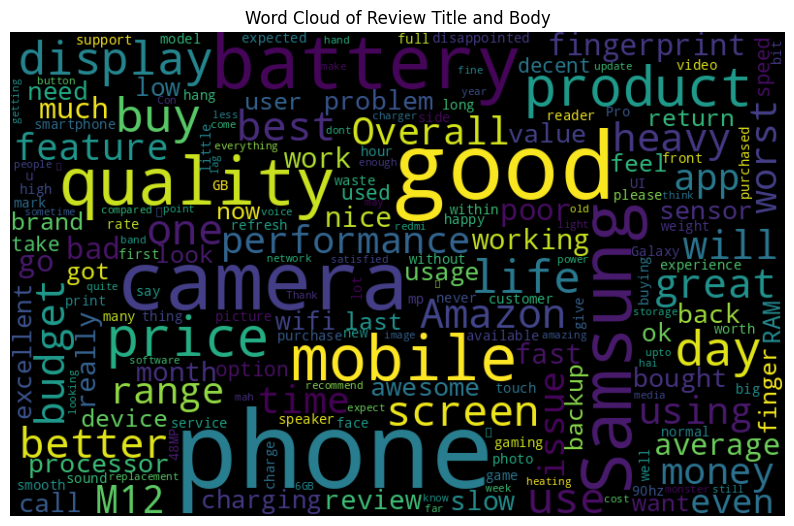

In [ ]:
try:
    from wordcloud import WordCloud
except ImportError:
    %pip install wordcloud
    from wordcloud import WordCloud

# Combine title and body for the word cloud
all_words = ' '.join([text for text in df['title'].fillna('') + ' ' + df['body'].fillna('')])

wordcloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110, collocations=False).generate(all_words)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Review Title and Body')
plt.show()

Find the Most Frequent Words

Most Frequent Words (excluding general stop words, retaining sentiment words):
phone: 1879
good: 1477
not: 1393
camera: 1074
battery: 891
samsung: 805
very: 739
quality: 719
mobile: 619
are: 459
price: 457
product: 432
have: 385
buy: 345
if: 342
display: 325
also: 322
life: 316
no: 301
like: 289


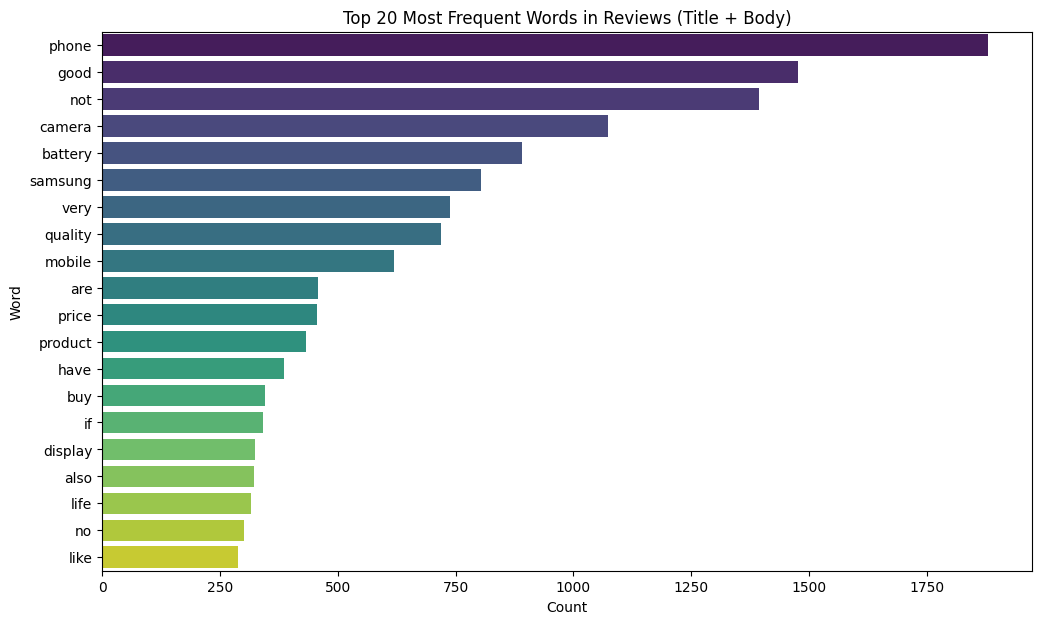

In [ ]:
from collections import Counter
import re

# Combine all review titles and bodies into a single string
all_words_combined = ' '.join(
    (df['title'].fillna('') + ' ' + df['body'].fillna('')).str.lower()
)

# Tokenize the words, removing punctuation and non-alphabetic characters
words = re.findall(r'\b[a-z]+\b', all_words_combined)

# Filter out common stop words, ensuring 'not', 'no', 'nor' are kept
stop_words = set([
    'a', 'an', 'the', 'is', 'it', 'and', 'or', 'to', 'of', 'for', 'with', 'in', 'on', 'at', 'this', 'that',
    'i', 'you', 'he', 'she', 'we', 'they', 'my', 'your', 'his', 'her', 'its', 'our', 'their', 'me', 'him', 'us', 'them',
    'from', 'by', 'as', 'but', 'so', 'can', 'will', 'just', 'do', 't', 's', 'm', 're', 've', 'll', 'all'
])

# Words to explicitly keep for sentiment analysis
words_to_keep = {'not', 'no', 'nor'}

# Filter stop words, but ensure words_to_keep are always included if present
filtered_words = [word for word in words if word not in stop_words or word in words_to_keep]

# Get the most common words
most_common_words = Counter(filtered_words).most_common(20)

# Display the most frequent words
print("Most Frequent Words (excluding general stop words, retaining sentiment words):")
for word, count in most_common_words:
    print(f"{word}: {count}")

# Visualize the most frequent words
words_df = pd.DataFrame(most_common_words, columns=['Word', 'Count'])

plt.figure(figsize=(12, 7))
sns.barplot(x='Count', y='Word', data=words_df, palette='viridis')
plt.title('Top 20 Most Frequent Words in Reviews (Title + Body)')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

Create Sentiment Labels and Analyze Distribution

Sentiment Distribution:
sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64


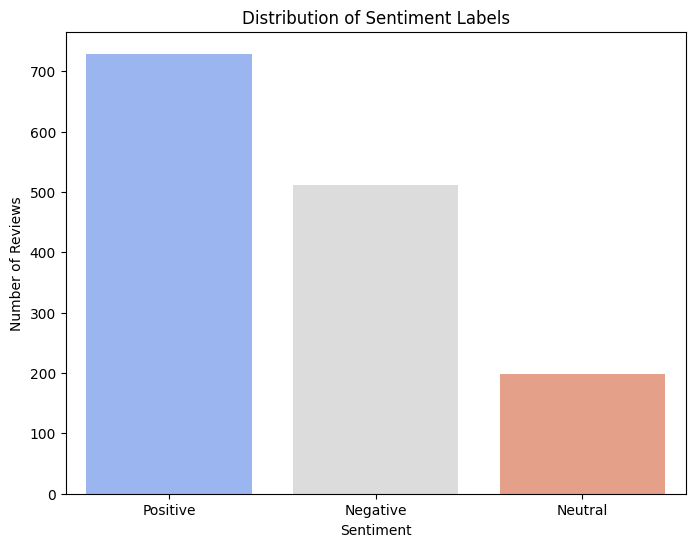

In [ ]:
# Define a function to map ratings to sentiment labels
def get_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

# Apply the function to create a new 'sentiment' column
df['sentiment'] = df['rating'].apply(get_sentiment)

# Display the distribution of sentiment labels
sentiment_distribution = df['sentiment'].value_counts()
print("Sentiment Distribution:")
print(sentiment_distribution)

# Visualize the sentiment distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_distribution.index, y=sentiment_distribution.values, palette='coolwarm')
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

Add percentage distribution for sentiment

In [ ]:
def get_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['rating'].apply(get_sentiment)

In [ ]:
print(df[['rating', 'sentiment']].head())
print(df['sentiment'].value_counts())

   rating sentiment
0       1  Negative
1       3   Neutral
2       4  Positive
3       1  Negative
4       1  Negative
sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64


In [ ]:
sentiment_percentage = df['sentiment'].value_counts(normalize=True) * 100
print(sentiment_percentage)

sentiment
Positive    50.625000
Negative    35.555556
Neutral     13.819444
Name: proportion, dtype: float64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [ ]:
import re
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))

# Keep important negative words
stop_words.discard('not')
stop_words.discard('no')
stop_words.discard('nor')

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove numbers and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()

    # Stopword removal + Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
df['Cleaned_Review'] = df['Translated_Review'].fillna('').apply(clean_text)

df[['Translated_Review', 'Cleaned_Review', 'sentiment']].head()

,Translated_Review,Cleaned_Review,sentiment
0,Horrible product Very disappointed with the ov...,horrible product disappointed overall performa...,Negative
1,Camera quality is not like 48 megapixel Camera...,camera quality not like megapixel camera quali...,Neutral
2,"Overall Got the mobile on the launch date,Batt...",overall got mobile launch date battery must ap...,Positive
3,A big no from me 1. It doesn't work with 5.0GH...,big no work ghz wifi frequency ghz old school ...,Negative
4,Put your money somewhere else Not worth buying...,put money somewhere else not worth buying faul...,Negative


In [ ]:
X = df['Cleaned_Review']
y = df['sentiment']

print(X.shape)
print(y.shape)

print("\nSentiment Distribution:")
print(y.value_counts())

(1440,)
(1440,)

Sentiment Distribution:
sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1152
Testing samples: 288


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (1152, 5636)
Testing shape: (288, 5636)


In [ ]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.80      0.78       102
     Neutral       0.32      0.30      0.31        40
    Positive       0.85      0.84      0.84       146

    accuracy                           0.75       288
   macro avg       0.65      0.65      0.65       288
weighted avg       0.75      0.75      0.75       288



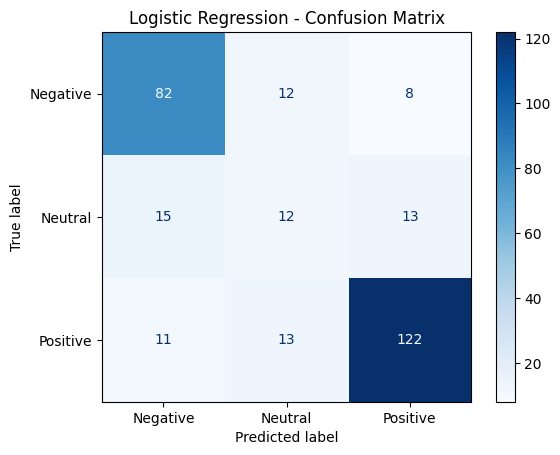

In [ ]:
cm = confusion_matrix(
    y_test,
    lr_pred,
    labels=['Negative', 'Neutral', 'Positive']
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Neutral', 'Positive']
)

disp.plot(cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:",
      accuracy_score(y_test, nb_pred))

print("\nClassification Report:")
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.7673611111111112

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.75      0.79       102
     Neutral       0.00      0.00      0.00        40
    Positive       0.73      0.99      0.84       146

    accuracy                           0.77       288
   macro avg       0.52      0.58      0.55       288
weighted avg       0.67      0.77      0.71       288



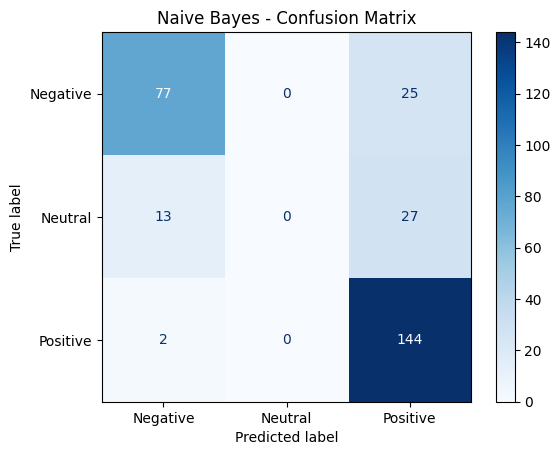

In [ ]:
cm = confusion_matrix(
    y_test,
    nb_pred,
    labels=['Negative', 'Neutral', 'Positive']
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Neutral', 'Positive']
)

disp.plot(cmap='Blues')
plt.title("Naive Bayes - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

print("Linear SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

Linear SVM Accuracy: 0.7743055555555556

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.84      0.79       102
     Neutral       0.38      0.20      0.26        40
    Positive       0.85      0.88      0.87       146

    accuracy                           0.77       288
   macro avg       0.66      0.64      0.64       288
weighted avg       0.75      0.77      0.76       288



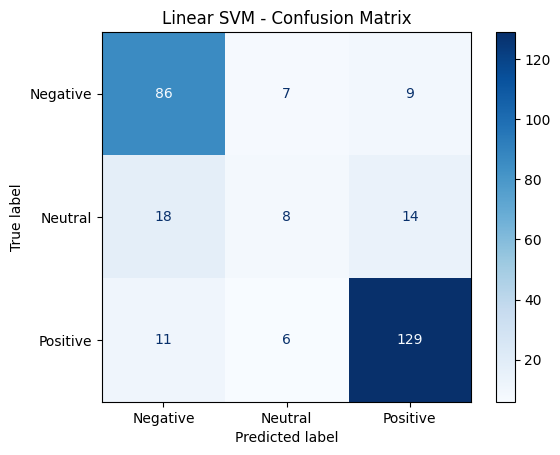

In [ ]:
cm = confusion_matrix(
    y_test,
    svm_pred,
    labels=['Negative', 'Neutral', 'Positive']
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Neutral', 'Positive']
)

disp.plot(cmap='Blues')
plt.title("Linear SVM - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'Linear SVM'
    ],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred)
    ],

    'Precision': [
        precision_score(y_test, lr_pred, average='macro'),
        precision_score(y_test, nb_pred, average='macro'),
        precision_score(y_test, svm_pred, average='macro')
    ],

    'Recall': [
        recall_score(y_test, lr_pred, average='macro'),
        recall_score(y_test, nb_pred, average='macro'),
        recall_score(y_test, svm_pred, average='macro')
    ],

    'F1 Score': [
        f1_score(y_test, lr_pred, average='macro'),
        f1_score(y_test, nb_pred, average='macro'),
        f1_score(y_test, svm_pred, average='macro')
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.750000,0.645577,0.646513,0.645644
1,Naive Bayes,0.767361,0.523883,0.580401,0.545307
2,Linear SVM,0.774306,0.659154,0.642233,0.640231


In [ ]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

    Negative       0.75      0.84      0.79       102
     Neutral       0.38      0.20      0.26        40
    Positive       0.85      0.88      0.87       146

    accuracy                           0.77       288
   macro avg       0.66      0.64      0.64       288
weighted avg       0.75      0.77      0.76       288



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

rf_pred = rf_model.predict(X_test_tfidf)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7708333333333334

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.80      0.79       102
     Neutral       0.67      0.05      0.09        40
    Positive       0.77      0.95      0.85       146

    accuracy                           0.77       288
   macro avg       0.74      0.60      0.58       288
weighted avg       0.76      0.77      0.72       288



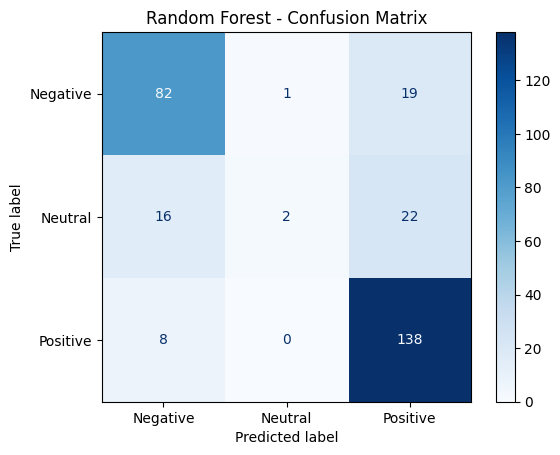

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=['Negative', 'Neutral', 'Positive']
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Neutral', 'Positive']
)

disp.plot(cmap='Blues')

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'Linear SVM',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, rf_pred)
    ],

    'Precision': [
        precision_score(y_test, lr_pred, average='macro'),
        precision_score(y_test, nb_pred, average='macro'),
        precision_score(y_test, svm_pred, average='macro'),
        precision_score(y_test, rf_pred, average='macro')
    ],

    'Recall': [
        recall_score(y_test, lr_pred, average='macro'),
        recall_score(y_test, nb_pred, average='macro'),
        recall_score(y_test, svm_pred, average='macro'),
        recall_score(y_test, rf_pred, average='macro')
    ],

    'F1 Score': [
        f1_score(y_test, lr_pred, average='macro'),
        f1_score(y_test, nb_pred, average='macro'),
        f1_score(y_test, svm_pred, average='macro'),
        f1_score(y_test, rf_pred, average='macro')
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.750000,0.645577,0.646513,0.645644
1,Naive Bayes,0.767361,0.523883,0.580401,0.545307
2,Linear SVM,0.774306,0.659154,0.642233,0.640231
3,Random Forest,0.770833,0.737067,0.599709,0.576905


In [ ]:
import joblib
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!
